Import libraries

In [64]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt 
import seaborn as sns
import keras 
import tensorflow as tf 
from keras.layers import Dense , Dropout , Flatten , Conv2D , MaxPool2D , BatchNormalization , GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint

Data Preprocessing

In [65]:
ROOT_DIR = r"D:\al_test\pythonXvs\Automated Traffic Sign Project\automate 3 CNN\traffic_Data"
IMG_SIZE = (128, 128)

train_df = pd.read_csv(os.path.join(ROOT_DIR, "Train.csv"))
test_df  = pd.read_csv(os.path.join(ROOT_DIR, "Test.csv"))

In [66]:
BLUR_THRESHOLD = 100
def fix_brightness(img_array):
    img_yuv = cv2.cvtColor(img_array, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    return cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

def is_blurry(img_array, threshold=BLUR_THRESHOLD):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

In [67]:
def load_data(df):
    images = []
    labels = []

    for _, row in df.iterrows():
        try:
            img_path = os.path.join(ROOT_DIR, row['Path'])
            img = Image.open(img_path).convert('RGB')

            
            x1, y1, x2, y2 = int(row['Roi.X1']), int(row['Roi.Y1']), int(row['Roi.X2']), int(row['Roi.Y2'])
            img = img.crop((x1, y1, x2, y2))

            
            img = img.resize(IMG_SIZE)

            img = np.array(img)


            images.append(img)
            labels.append(int(row['ClassId']))

        except:
            continue

    return np.array(images), np.array(labels)

In [68]:
x_train, y_train = load_data(train_df)
x_test, y_test   = load_data(test_df)

In [69]:
print(len(x_train), len(y_train))

39209 39209


In [70]:
class_names = {
    0:  'Speed limit 20',       1:  'Speed limit 30',
    2:  'Speed limit 50',       3:  'Speed limit 60',
    4:  'Speed limit 70',       5:  'Speed limit 80',
    6:  'End speed limit 80',   7:  'Speed limit 100',
    8:  'Speed limit 120',      9:  'No passing',
    10: 'No passing >3.5t',     11: 'Right of way',
    12: 'Priority road',        13: 'Yield',
    14: 'Stop',                 15: 'No vehicles',
    16: 'No vehicles >3.5t',    17: 'No entry',
    18: 'General caution',      19: 'Curve left',
    20: 'Curve right',          21: 'Double curve',
    22: 'Bumpy road',           23: 'Slippery road',
    24: 'Road narrows right',   25: 'Road work',
    26: 'Traffic signals',      27: 'Pedestrians',
    28: 'Children crossing',    29: 'Bicycles crossing',
    30: 'Ice/Snow',             31: 'Wild animals',
    32: 'End restrictions',     33: 'Turn right ahead',
    34: 'Turn left ahead',      35: 'Go straight',
    36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right',           39: 'Keep left',
    40: 'Roundabout',           41: 'End no passing',
    42: 'End no passing >3.5t'
}

EDA

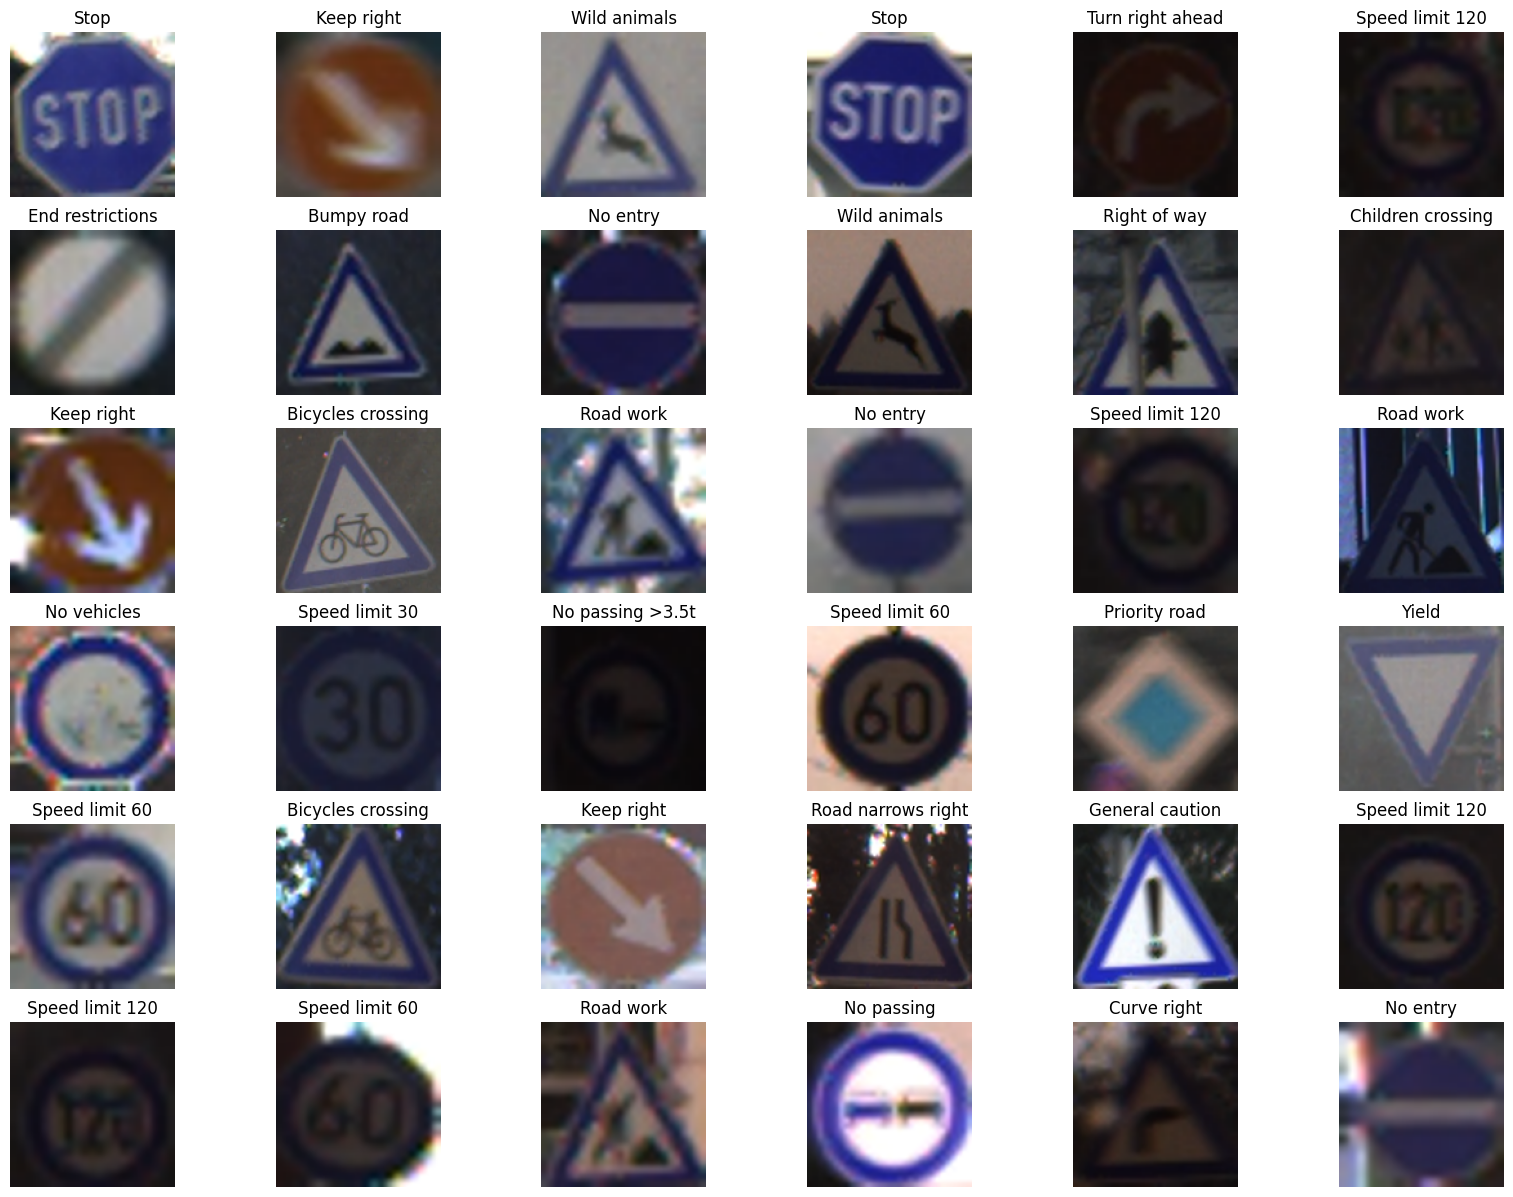

In [71]:
plt.figure(figsize=(20 , 15 ))
for n , i in enumerate(np.random.randint(0 , len(x_train) , 36)):
    plt.subplot( 6 , 6 , n + 1)
    img = cv2.cvtColor(x_train[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(class_names[y_train[i]])
plt.show()

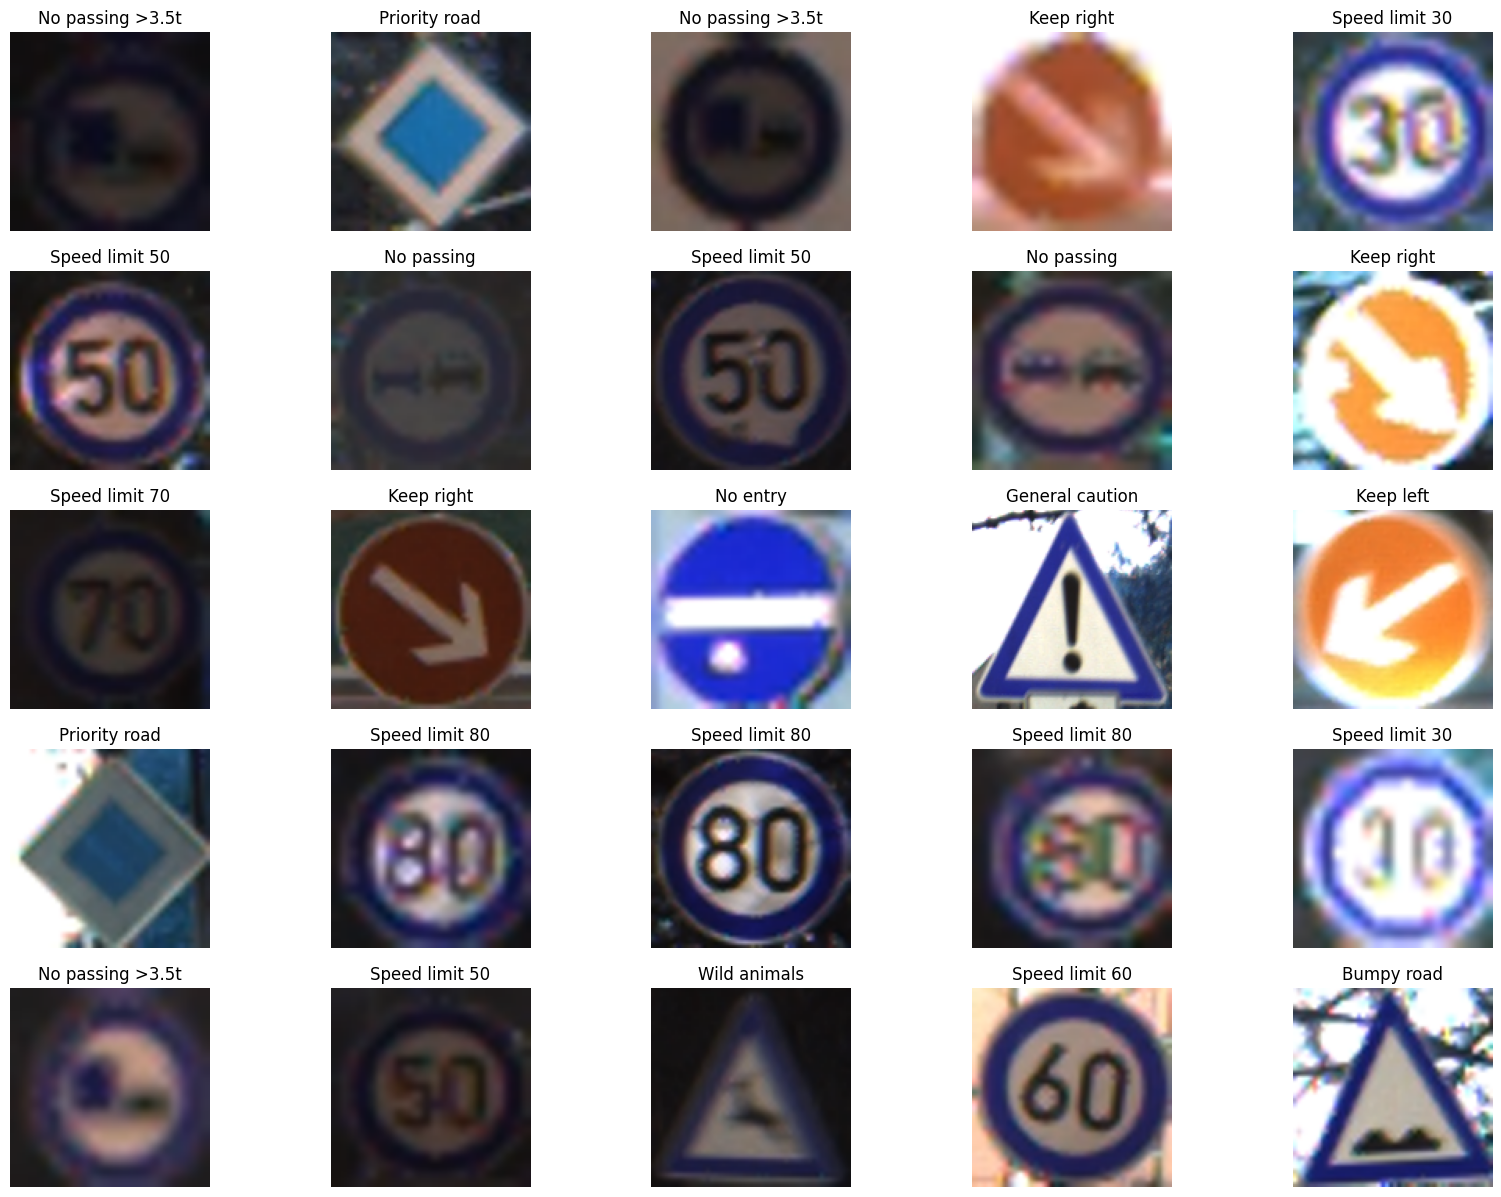

In [72]:
plt.figure(figsize=(20 , 15))
for n , i in enumerate(np.random.randint(0 , len(x_test) , 25)):
    plt.subplot( 5 , 5 , n + 1)
    img = cv2.cvtColor(x_test[i] , cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(class_names[y_test[i]])
plt.show()

In [73]:
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [74]:
x_train.shape

(39209, 128, 128, 3)

Train The Model

In [75]:
keras_model = keras.models.Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(43, activation='softmax') 
])

keras_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

d:\al_test\pythonXvs\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
keras_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,02

 Total params: 822,283 (3.14 MB)

 Trainable params: 820,491 (3.13 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [77]:
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

In [78]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

In [79]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [80]:
callbacks = [earlystop, learning_rate_reduction,checkpoint]

In [81]:
train_df['Path'] = train_df['Path'].apply(lambda x: os.path.join(ROOT_DIR, x))
test_df['Path']  = test_df['Path'].apply(lambda x: os.path.join(ROOT_DIR, x))


In [82]:
from sklearn.model_selection import train_test_split

train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['ClassId'],
    random_state=42
)

In [83]:
train_df_split['ClassId'] = train_df_split['ClassId'].astype(str)
val_df_split['ClassId']   = val_df_split['ClassId'].astype(str)
test_df['ClassId']        = test_df['ClassId'].astype(str)

In [84]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 24
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_split,
    x_col='Path',
    y_col='ClassId',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=val_df_split,
    x_col='Path',
    y_col='ClassId',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='Path',
    y_col='ClassId',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 25094 validated image filenames belonging to 43 classes.
Found 1568 validated image filenames belonging to 43 classes.
Found 12630 validated image filenames belonging to 43 classes.


In [85]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

In [86]:
history = keras_model.fit(
    train_generator,
    epochs=80,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 435s 411ms/step - accuracy: 0.5915 - loss: 1.5598 - val_accuracy: 0.9528 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch 2/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 455s 435ms/step - accuracy: 0.9572 - loss: 0.1559 - val_accuracy: 0.9809 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 3/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 447s 428ms/step - accuracy: 0.9758 - loss: 0.0846 - val_accuracy: 0.9841 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 4/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9821 - loss: 0.0625
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 454s 434ms/step - accuracy: 0.9797 - loss: 0.0682 - val_accuracy: 0.9477 - val_loss: 0.1777 - learning_rate: 0.0010
Epoch 5/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 419s 400ms/step - accuracy: 0.9929 - loss: 0.0247 - val_accuracy: 0.9981 - val_loss: 0.0084 - learning_rate: 5.0000e-04
Epoch 6/80
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 408s 390m

In [87]:

val_loss, val_accuracy = keras_model.evaluate(val_generator)


print(f'val loss: {val_loss}')
print(f'val accuracy: {val_accuracy * 100} %')


66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9974 - loss: 0.0088
val loss: 0.008801035583019257
val accuracy: 99.7448980808258 %


In [88]:

test_loss, test_accuracy = keras_model.evaluate(test_generator)

print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy * 100} %')


527/527 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - accuracy: 0.9878 - loss: 0.0428
Test loss: 0.04281993955373764
Test accuracy: 98.78067970275879 %


In [89]:
y_true = test_generator.classes

y_pred = keras_model.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)


527/527 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step


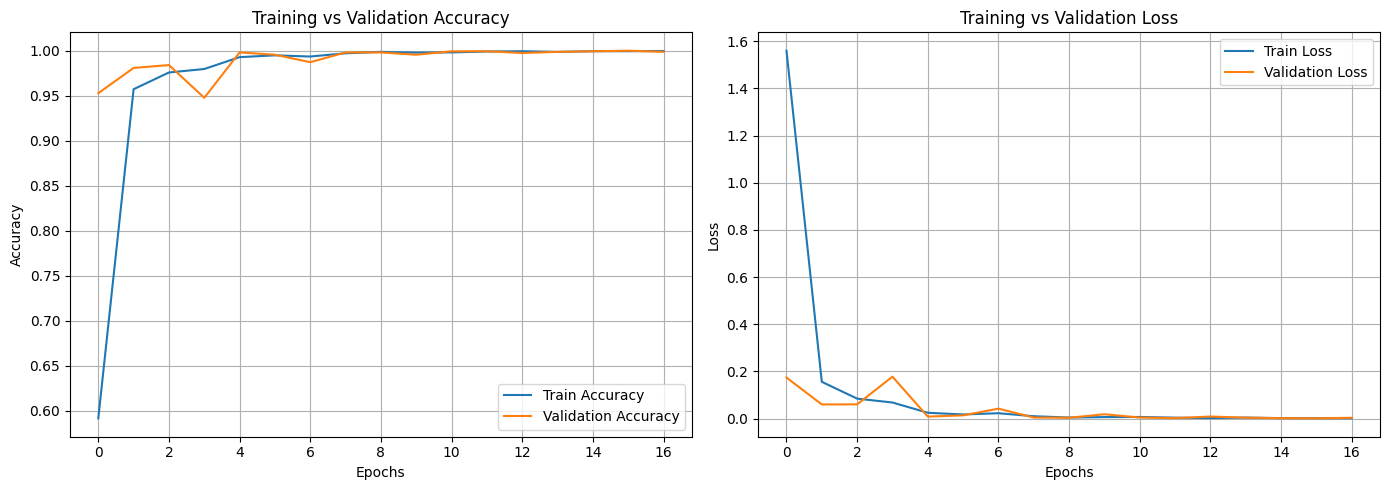

In [90]:
plt.figure(figsize=(14,5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


527/527 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step


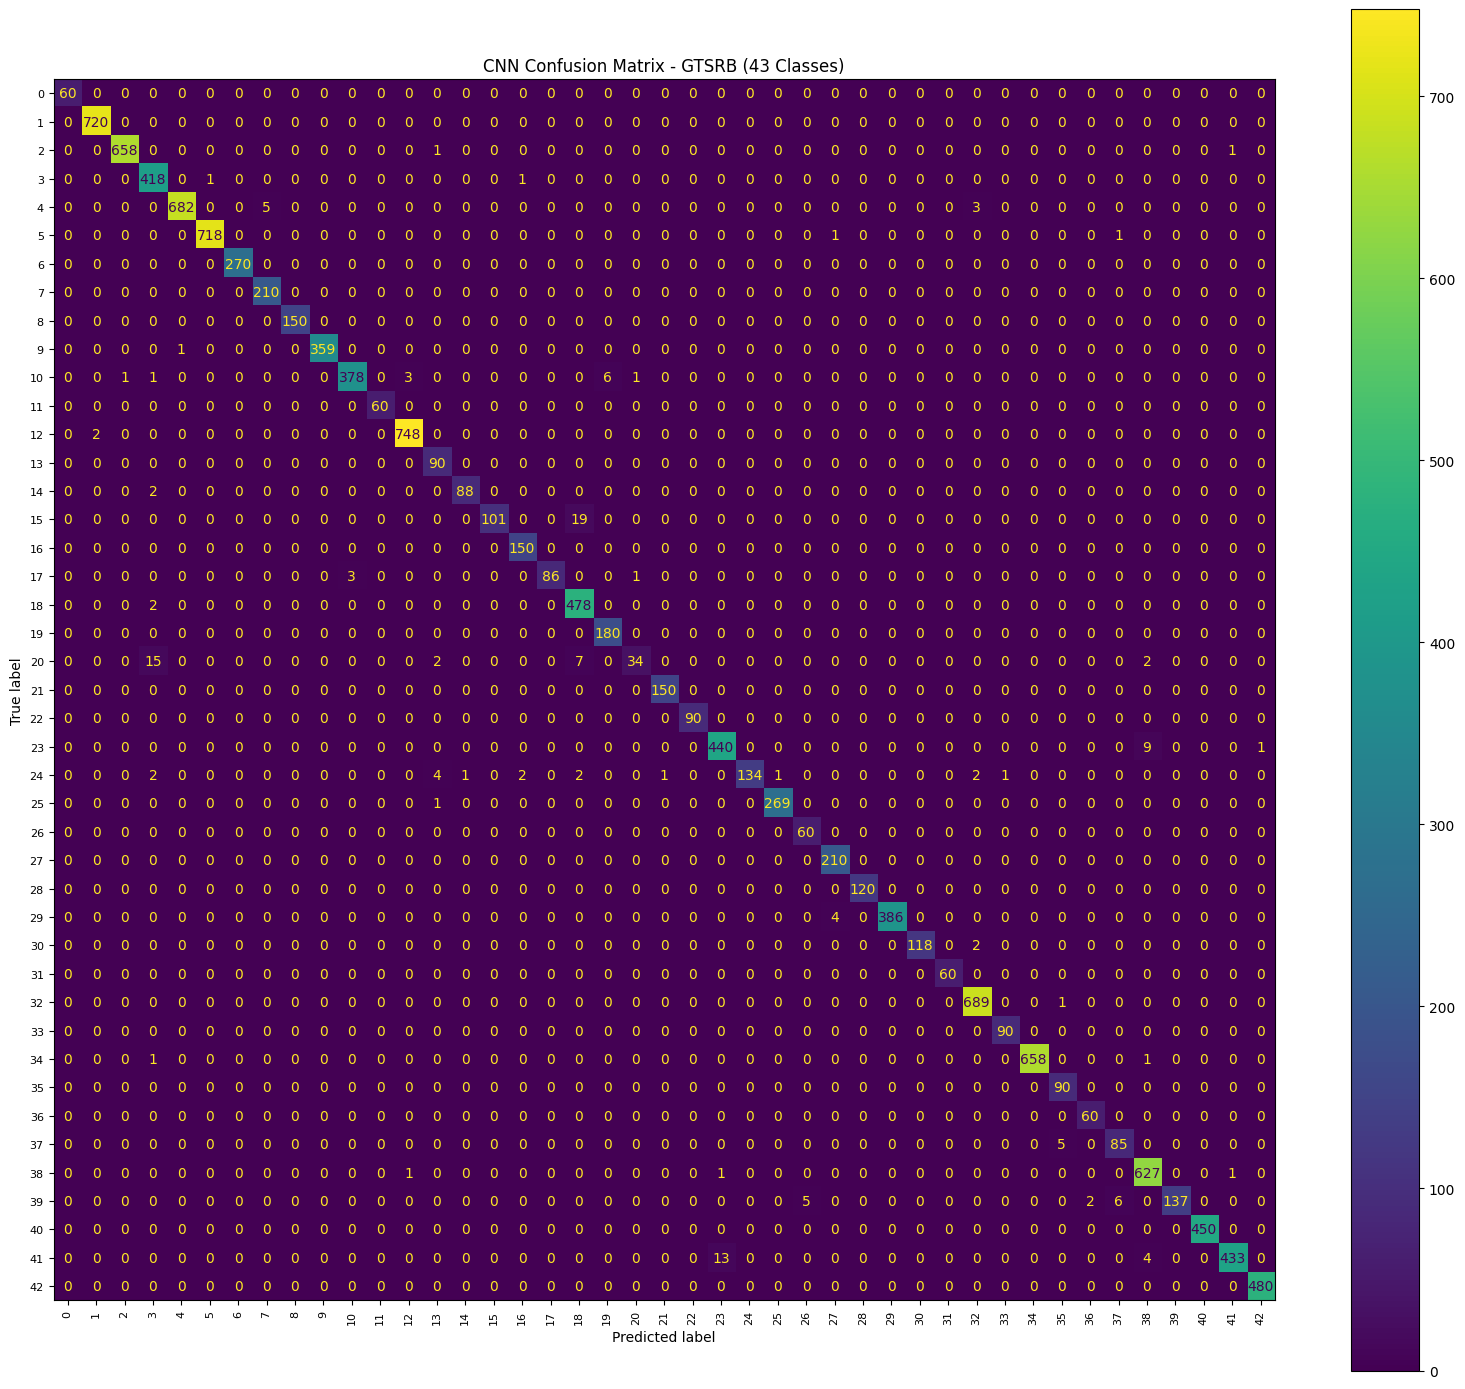

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# After getting predictions from your CNN/YOLO model
y_true = test_generator.classes  # Ground truth labels (0-42 for GTSRB)
y_pred = model.predict(test_generator)  # Model predictions
y_pred = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(43))
disp.plot(ax=ax, cmap='viridis', values_format='d')
plt.title('CNN Confusion Matrix - GTSRB (43 Classes)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

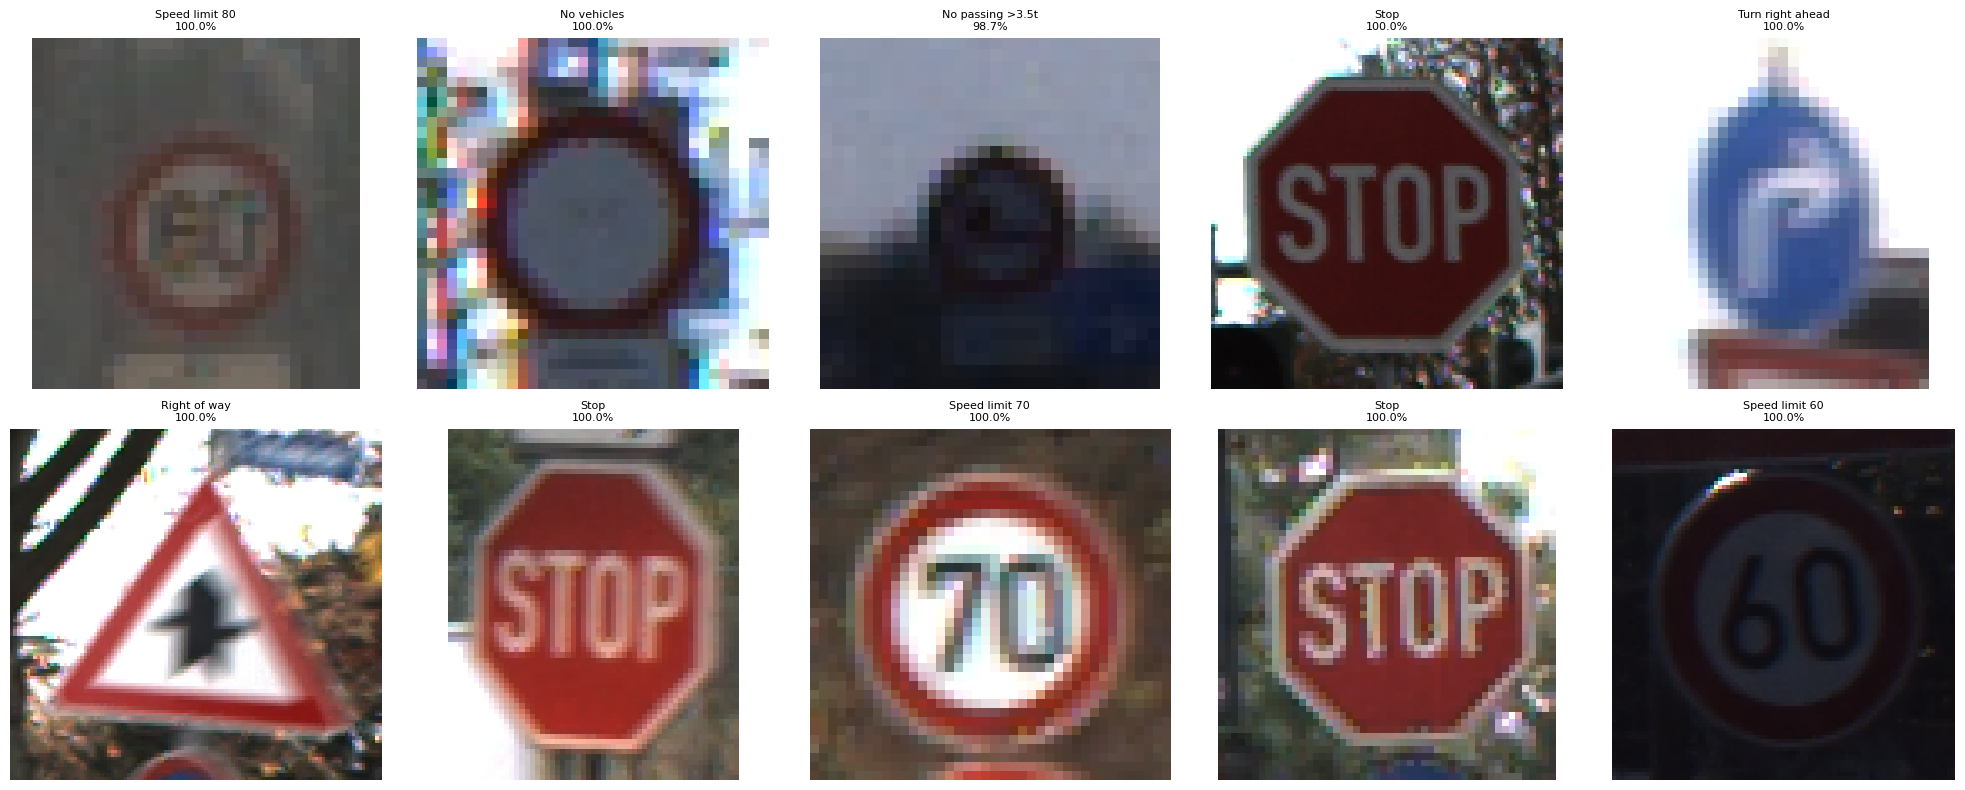

In [99]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model(r"D:\al_test\pythonXvs\Automated Traffic Sign Project\automate 3 CNN\traffic_Data\best_model.keras")

# YOUR ACTUAL CLASS MAPPING (reversed)
class_mapping = {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, 
                 '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, 
                 '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, 
                 '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, 
                 '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, 
                 '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}

# REVERSE: index -> folder_name (actual class)
index_to_actual_class = {v: int(k) for k, v in class_mapping.items()}

# GTSRB Labels (by actual class number)
class_names = {
    0:  'Speed limit 20',       1:  'Speed limit 30',
    2:  'Speed limit 50',       3:  'Speed limit 60',
    4:  'Speed limit 70',       5:  'Speed limit 80',
    6:  'End speed limit 80',   7:  'Speed limit 100',
    8:  'Speed limit 120',      9:  'No passing',
    10: 'No passing >3.5t',     11: 'Right of way',
    12: 'Priority road',        13: 'Yield',
    14: 'Stop',                 15: 'No vehicles',
    16: 'No vehicles >3.5t',    17: 'No entry',
    18: 'General caution',      19: 'Curve left',
    20: 'Curve right',          21: 'Double curve',
    22: 'Bumpy road',           23: 'Slippery road',
    24: 'Road narrows right',   25: 'Road work',
    26: 'Traffic signals',      27: 'Pedestrians',
    28: 'Children crossing',    29: 'Bicycles crossing',
    30: 'Ice/Snow',             31: 'Wild animals',
    32: 'End restrictions',     33: 'Turn right ahead',
    34: 'Turn left ahead',      35: 'Go straight',
    36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right',           39: 'Keep left',
    40: 'Roundabout',           41: 'End no passing',
    42: 'End no passing >3.5t'
}

test_folder = r"D:\al_test\pythonXvs\Automated Traffic Sign Project\automate 3 CNN\traffic_Data\Test"  # Change this
test_images = [f for f in os.listdir(test_folder)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

sample = random.sample(test_images, min(10, len(test_images)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, img_file in zip(axes, sample):
    img_path = os.path.join(test_folder, img_file)
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_array = np.expand_dims(img_resized / 255.0, axis=0).astype('float32')
    
    pred = model.predict(img_array, verbose=0)
    pred_index = np.argmax(pred)
    confidence = np.max(pred)
    
    # KEY FIX: Convert model index → actual class → label
    actual_class = index_to_actual_class[pred_index]
    label = class_names[actual_class]
    
    ax.imshow(img_rgb)
    ax.set_title(f"{label}\n{confidence:.1%}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()